> # **Efficiency vs. Alignment: Assessing Decoding Strategies as a Practical Alternative to Full RLHF in Low-Resource Korean LLM Settings**

<br><br/>
선행 조건 (Prerequisites):

이 실험 코드는 **KoChatGPT_trained_models_eval.py (GD09)** 의 연장선이다.
아래 세 모델이 GD09에서 학습 완료되어 로컬에 저장되어 있어야 실행 가능하다.

| 모델 | 경로 | 설명 |
|------|------|------|
| KoGPT-2 Base | `skt/kogpt2-base-v2` | 사전학습 베이스 모델 (HuggingFace 자동 다운로드) |
| SFT | `models/output_1_SFT_upgr` | GD09에서 Supervised Fine-Tuning 완료된 모델 |
| PPO | `models/output_3_PPO_upgr` | GD09에서 RLHF(SFT→RM→PPO) 완료된 모델 |

이 파일은 세 모델을 **재학습하지 않는다.**
오직 디코딩 전략(Default vs Tuned)만 변수로 삼아 추론 및 평가를 수행한다.

실험 목적:

시간/데이터/컴퓨팅이 제한된 저자원 환경에서,
RLHF 전체 파이프라인(SFT→RM→PPO)보다
SFT + 디코딩 전략 최적화가 더 효율적인 대안이 될 수 있는지 검증한다.

### 1. 환경 설정

In [1]:
# 라이브러리 호출
import sys
import os
import gc
import time
import random
import warnings
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from scipy import stats
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
 
warnings.filterwarnings('ignore')

In [2]:
# KoChatGPT 패키지 경로 추가
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
 
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer.strategies import NaiveStrategy

In [3]:
# 경로 설정
MODEL_SFT  = 'models/output_1_SFT_upgr'
MODEL_RM   = 'models/output_2_RM_upgr'
MODEL_PPO  = 'models/output_3_PPO_upgr'
BASE_MODEL = 'skt/kogpt2-base-v2'
SAVE_DIR   = 'paper_results'
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# 시드 고정
SEED = 42
 
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
set_seed(SEED)

In [5]:
# 디바이스 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
      if torch.cuda.is_available() else "")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


In [6]:
# 토크나이저 로드
def load_tokenizer(path: str = BASE_MODEL) -> PreTrainedTokenizerFast:
    """
    KoGPT-2용 fast tokenizer 로드.
    AutoTokenizer 대신 PreTrainedTokenizerFast를 명시적으로 사용:
    - slow tokenizer는 한글을 UTF-8 바이트로 분해해 디코딩이 깨짐
    - fast tokenizer는 한글 단어 단위 토큰화 정상 작동
    """
    return PreTrainedTokenizerFast.from_pretrained(
        path,
        bos_token='</s>',
        eos_token='</s>',
        unk_token='<unk>',
        pad_token='</s>',
        padding_side='right',
        model_max_length=512,
    )
 
tokenizer = load_tokenizer(MODEL_SFT)

In [7]:
# 인코딩 - 디코딩 테스트
test_text = '불고기용 고기 한우에요?'
decoded = tokenizer.decode(tokenizer.encode(test_text, return_tensors='pt')[0],
                            skip_special_tokens=True)
assert decoded == test_text, f"토크나이저 이상: {decoded}"
print(f"토크나이저 로드 완료: {type(tokenizer).__name__}")

토크나이저 로드 완료: TokenizersBackend


### 디코딩 전략 정의

논문의 핵심 독립변수. Default와 Tuned를 고정 정의해 cherry-picking이 아닌 공정한 비교임을 보장한다.

In [8]:
PROMPT_TEMPLATE = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
 
# ── Default: greedy decoding ──────────────────────────────────────────
# 디코딩 전략을 전혀 적용하지 않은 baseline
# do_sample=False → 항상 가장 높은 확률 토큰 선택 (greedy)
DECODING_DEFAULT = dict(
    do_sample=False,
    num_beams=1,
    max_new_tokens=150,
    repetition_penalty=1.0,
    # no_repeat_ngram_size 미적용
)
 
# ── Tuned: GD09 프로젝트에서 검증된 최적 디코딩 전략 ─────────────────
# num_beams=4:              greedy 대비 품질 높은 시퀀스 탐색
# do_sample=True:           확률 분포 기반 샘플링 활성화
# temperature=0.7:          낮을수록 보수적, 높을수록 무작위 (균형점)
# top_k=50 / top_p=0.92:   상위 토큰 필터링으로 무의미한 토큰 억제
# repetition_penalty=1.3:  이미 생성한 토큰 재생성 확률 억제
# no_repeat_ngram_size=4:  4-gram 단위 반복 구간 차단
DECODING_TUNED = dict(
    do_sample=True,
    num_beams=4,
    temperature=0.7,
    top_k=50,
    top_p=0.92,
    max_new_tokens=150,
    repetition_penalty=1.3,
    no_repeat_ngram_size=4,
    early_stopping=True,
)
 
print("디코딩 전략 정의 완료")
print()
print(f"  Default 파라미터:\n {DECODING_DEFAULT}")
print()
print(f"  Tuned   파라미터:\n {DECODING_TUNED}")

디코딩 전략 정의 완료

  Default 파라미터:
 {'do_sample': False, 'num_beams': 1, 'max_new_tokens': 150, 'repetition_penalty': 1.0}

  Tuned   파라미터:
 {'do_sample': True, 'num_beams': 4, 'temperature': 0.7, 'top_k': 50, 'top_p': 0.92, 'max_new_tokens': 150, 'repetition_penalty': 1.3, 'no_repeat_ngram_size': 4, 'early_stopping': True}


### 3. 평가 프롬프트 정의

모델 훈련 시 사용했던 프롬프트를 그대로 사용해 일관성을 확보했다.

In [9]:
EVAL_PROMPTS_RAW = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '오늘 미세먼지 어때?',
    '과제를 빠르고도 정확하게 끝내는 방법이 뭐야?',
]
 
EVAL_PROMPTS = [PROMPT_TEMPLATE.format(prompt=p) for p in EVAL_PROMPTS_RAW]
 
print(f"평가 프롬프트 {len(EVAL_PROMPTS)}개 준비 완료")
for i, p in enumerate(EVAL_PROMPTS_RAW):
    print(f"  Q{i+1}: {p}")

평가 프롬프트 5개 준비 완료
  Q1: 불고기용 고기 한우에요?
  Q2: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
  Q3: 시카고 오헤어 국제공항은 어디에 있어?
  Q4: 오늘 미세먼지 어때?
  Q5: 과제를 빠르고도 정확하게 끝내는 방법이 뭐야?


### 4. 모델 로드 및 추론

**OOM 방지 전략:**
- 모델을 한 번에 하나씩만 메모리에 올림
- 각 모델 추론 완료 후 즉시 del + empty_cache()
- fp16은 추론 시 사용하지 않음 (KoGPT-2 125M은 충분히 가벼움)

In [10]:
def generate_response(prompt: str, model, tokenizer, decoding_kwargs: dict) -> tuple:
    """
    프롬프트와 디코딩 전략을 받아 (응답 텍스트, 추론 소요 시간(초)) 튜플을 반환한다.

    - GPTActor는 .model 속성이 실제 GPT2LMHeadModel → hasattr로 자동 판별
    - max_new_tokens 사용: 프롬프트 길이와 무관하게 응답 길이 제어
    - decode (batch_decode 아님): outputs[0]은 1D 텐서
    - time.perf_counter(): GPU 동기화 후 측정해 정확한 추론 시간 확보
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    gen_model = model.model if hasattr(model, 'model') else model
    kwargs    = {**decoding_kwargs, 'eos_token_id': tokenizer.eos_token_id}

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        output_ids = gen_model.generate(input_ids, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    full_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )
    return full_text[len(prompt):].strip(), elapsed


# ── 효율성 지표 저장소 ────────────────────────────────────────────────
# 논문의 비용(Cost) 측면 근거 데이터
# 컬럼: model / decoding / q_idx / time_sec / vram_peak_gb
efficiency_log = []


def run_inference_for_model(model, model_label: str, tokenizer) -> dict:
    """
    한 모델에 대해 Default / Tuned 디코딩 모두 실행하고 결과 반환.
    추론 시간(time.perf_counter)과 VRAM 피크(reset_peak_memory_stats)를
    efficiency_log에 기록해 논문의 효율성 비교 근거로 활용한다.
    결과 형식: {prompt_idx: {'default': response, 'tuned': response}}
    """
    model.eval()
    results      = {}
    resp_cache   = {}   # (q_idx, dec_label) -> response 텍스트 캐시 (중복 생성 방지)

    for i, (raw, prompt) in enumerate(zip(EVAL_PROMPTS_RAW, EVAL_PROMPTS)):
        for dec_label, dec_kwargs in [('Default', DECODING_DEFAULT),
                                       ('Tuned',   DECODING_TUNED)]:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()

            response, elapsed = generate_response(prompt, model, tokenizer, dec_kwargs)

            vram_peak = (torch.cuda.max_memory_allocated() / 1024**3
                         if torch.cuda.is_available() else 0.0)

            efficiency_log.append({
                'model':        model_label.upper(),
                'decoding':     dec_label,
                'q_idx':        i + 1,
                'time_sec':     round(elapsed, 4),
                'vram_peak_gb': round(vram_peak, 3),
            })
            resp_cache[(i, dec_label)] = response

        results[i] = {
            'question': raw,
            'default':  resp_cache[(i, 'Default')],
            'tuned':    resp_cache[(i, 'Tuned')],
        }
        t_def = next(e['time_sec'] for e in efficiency_log
                     if e['model'] == model_label.upper()
                     and e['decoding'] == 'Default' and e['q_idx'] == i + 1)
        t_tun = next(e['time_sec'] for e in efficiency_log
                     if e['model'] == model_label.upper()
                     and e['decoding'] == 'Tuned' and e['q_idx'] == i + 1)
        print(f"  [{model_label}] Q{i+1} 완료  "
              f"(Default {t_def:.2f}s / Tuned {t_tun:.2f}s)")
    return results


# ── 결과 저장 딕셔너리 ────────────────────────────────────────────────
all_responses = {}  # {'base': {...}, 'sft': {...}, 'ppo': {...}}

### 4-1. Base 모델 추론

In [11]:
gc.collect()
torch.cuda.empty_cache()
print(f"Base 추론 전 VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(device)
base_model.eval()
print("KoGPT-2 Base 로드 완료")

all_responses['base'] = run_inference_for_model(base_model, 'Base', tokenizer)

del base_model
gc.collect()
torch.cuda.empty_cache()
print(f"Base 추론 완료 / VRAM 해제 후: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Base 추론 전 VRAM: 0.00 GB


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KoGPT-2 Base 로드 완료
  [Base] Q1 완료  (Default 1.60s / Tuned 2.23s)
  [Base] Q2 완료  (Default 1.36s / Tuned 2.09s)
  [Base] Q3 완료  (Default 1.44s / Tuned 2.11s)
  [Base] Q4 완료  (Default 1.39s / Tuned 2.04s)
  [Base] Q5 완료  (Default 1.34s / Tuned 2.18s)
Base 추론 완료 / VRAM 해제 후: 0.01 GB


### 4-2. SFT 모델 추론

In [12]:
gc.collect()
torch.cuda.empty_cache()
print(f"SFT 추론 전 VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

sft_model = AutoModelForCausalLM.from_pretrained(MODEL_SFT).to(device)
sft_model.eval()
print("SFT 모델 로드 완료")

all_responses['sft'] = run_inference_for_model(sft_model, 'SFT', tokenizer)

del sft_model
gc.collect()
torch.cuda.empty_cache()
print(f"SFT 추론 완료 / VRAM 해제 후: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

SFT 추론 전 VRAM: 0.01 GB


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


SFT 모델 로드 완료
  [SFT] Q1 완료  (Default 0.51s / Tuned 0.78s)
  [SFT] Q2 완료  (Default 0.14s / Tuned 0.25s)
  [SFT] Q3 완료  (Default 0.14s / Tuned 0.48s)
  [SFT] Q4 완료  (Default 0.70s / Tuned 0.92s)
  [SFT] Q5 완료  (Default 1.33s / Tuned 1.41s)
SFT 추론 완료 / VRAM 해제 후: 0.01 GB


### 4-3. PPO 모델 추론

In [13]:
gc.collect()
torch.cuda.empty_cache()
print(f"PPO 추론 전 VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

with NaiveStrategy().model_init_context():
    ppo_actor = GPTActor(pretrained=MODEL_PPO, lora_rank=0).to(device)
ppo_actor.eval()
print("PPO 모델 로드 완료")

all_responses['ppo'] = run_inference_for_model(ppo_actor, 'PPO', tokenizer)

del ppo_actor
gc.collect()
torch.cuda.empty_cache()
print(f"PPO 추론 완료 / VRAM 해제 후: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

PPO 추론 전 VRAM: 0.01 GB


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PPO 모델 로드 완료
  [PPO] Q1 완료  (Default 0.61s / Tuned 0.70s)
  [PPO] Q2 완료  (Default 0.69s / Tuned 0.32s)
  [PPO] Q3 완료  (Default 0.14s / Tuned 0.65s)
  [PPO] Q4 완료  (Default 0.82s / Tuned 1.33s)
  [PPO] Q5 완료  (Default 1.32s / Tuned 2.07s)
PPO 추론 완료 / VRAM 해제 후: 0.01 GB


### 4-4. 정성 평가용 응답 원문 출력

In [14]:
print("=" * 70)
print("정성 평가 — 6개 조건 응답 전체 출력")
print("=" * 70)

CONDITIONS = [
    ('base', 'default', 'Base   + Default'),
    ('base', 'tuned',   'Base   + Tuned  '),
    ('sft',  'default', 'SFT    + Default'),
    ('sft',  'tuned',   'SFT    + Tuned  '),
    ('ppo',  'default', 'PPO    + Default'),
    ('ppo',  'tuned',   'PPO    + Tuned  '),
]

for qi in range(len(EVAL_PROMPTS_RAW)):
    print(f"\nQ{qi+1}: {EVAL_PROMPTS_RAW[qi]}")
    print("-" * 60)
    for model_key, dec_key, label in CONDITIONS:
        resp = all_responses[model_key][qi][dec_key]
        print(f"  [{label}] {resp[:120]}")

정성 평가 — 6개 조건 응답 전체 출력

Q1: 불고기용 고기 한우에요?
------------------------------------------------------------
  [Base   + Default] ########################################################################################################################
  [Base   + Tuned  ] #food #delicious #selfie #foodstagram #instafood #20180413 #미롱_식단 
점심 : 닭가슴살샐러드
#diet #dieter #다이어트그램 #오늘의식단 #식단일기
#다이어트
  [SFT    + Default] 저는 인공지능 챗봇이므로 불고기용 고기의 종류를 알지 못합니다. 하지만 일반적으로 불고기용 고기는 쇠고기의 원산지와 유통기한 등을 고려하여 선택됩니다. 따라서 해당 고기의 원산지와 유통기한을 확인하시고 구매하시는 것
  [SFT    + Tuned  ] 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 쇠고기, 돼지고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다.
  [PPO    + Default] 저는 인공지능 챗봇이므로 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 한우보다 가격이 저렴하기 때문에 구매하시는 분들은 한우보다 저렴한 가격으로 구매하실 수 있습니다. 또한, 한우보다 더 많은 양의 
  [PPO    + Tuned  ] 저는 인공지능 어시스턴트이기 때문에 직접 고기를 먹을 수는 없습니다. 하지만 인터넷에서 검색해보시면 쉽게 고기를 찾을 수 있을 것 같습니다! 인터넷에서 검색해 보시면 더 자세한 정보를 얻으실 수 있을 것입니다.

Q2: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
---------------------------------------------

## 5. 정량 평가

**참조 기준:** SFT + Default (가장 중립적인 baseline)
- BLEU, ROUGE-1, ROUGE-L: SFT+Default 응답과의 유사도
- RM Reward Score: 학습된 보상 모델의 선호도 점수 (proxy human eval)

### 5-1. BLEU / ROUGE 계산

In [15]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rs
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

rouge_scorer = rs.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)
smoother     = SmoothingFunction().method1

# SFT+Default를 reference로 고정
# 해석 프레임: "SFT의 평균적 답변에서 얼마나 이탈했는가(Policy Shift)" 측정
# - BLEU↑ / RM↑ : 보수적 정렬 (기존 문체 유지하며 품질 향상)
# - BLEU↓ / RM↑ : 이상적 정렬 (SFT 문체를 탈피해 고품질 응답으로 진화 = Alignment Drift)
# - BLEU↓ / RM↓ : 모델 붕괴 (Collapse)
references = {qi: all_responses['sft'][qi]['default'] for qi in range(len(EVAL_PROMPTS_RAW))}

rows = []
for model_key, dec_key, label in CONDITIONS:
    for qi in range(len(EVAL_PROMPTS_RAW)):
        hyp = all_responses[model_key][qi][dec_key]
        ref = references[qi]

        bleu  = sentence_bleu([ref.split()], hyp.split(), smoothing_function=smoother)
        rouge = rouge_scorer.score(ref, hyp)
        r1    = rouge['rouge1'].fmeasure
        rl    = rouge['rougeL'].fmeasure

        # 토큰 길이: tokenizer 기반으로 측정 (공백 분리보다 정확)
        # Distinct-n의 length artifact 통제 변수로 활용
        token_len = len(tokenizer.encode(hyp))

        rows.append({
            'condition':    label.strip(),
            'model':        model_key.upper(),
            'decoding':     dec_key.capitalize(),
            'question':     EVAL_PROMPTS_RAW[qi],
            'q_idx':        qi + 1,
            'BLEU':         round(bleu, 4),
            'ROUGE-1':      round(r1,   4),
            'ROUGE-L':      round(rl,   4),
            'response':     hyp,
            'token_length': token_len,   # Distinct-n 통제 변수
        })

df = pd.DataFrame(rows)
print("BLEU / ROUGE 계산 완료")
print(df.groupby('condition')[['BLEU', 'ROUGE-1', 'ROUGE-L']].mean().round(4))

# ── Alignment Drift 해석 테이블 ───────────────────────────────────────
# BLEU와 RM_Reward는 아직 합산 전이므로 여기서는 조건별 BLEU 평균만 미리 출력.
# RM_Reward 계산(5-2) 후 섹션 6-2에서 Policy Shift 분류를 완성한다.
print("\n[조건별 평균 token_length — Distinct-n 통제 변수 사전 확인]")
print(df.groupby('condition')['token_length'].mean().round(1).to_string())

BLEU / ROUGE 계산 완료
                    BLEU  ROUGE-1  ROUGE-L
condition                                 
Base   + Default  0.0000   0.0000   0.0000
Base   + Tuned    0.0000   0.0000   0.0000
PPO    + Default  0.1932   0.2846   0.2846
PPO    + Tuned    0.0991   0.3333   0.3333
SFT    + Default  1.0000   0.4000   0.4000
SFT    + Tuned    0.1208   0.3053   0.3053

[조건별 평균 token_length — Distinct-n 통제 변수 사전 확인]
condition
Base   + Default    150.0
Base   + Tuned      144.6
PPO    + Default     77.6
PPO    + Tuned       65.8
SFT    + Default     61.0
SFT    + Tuned       46.4


### 5-1-1. 다양성 지표: Self-BLEU & Distinct-n

**왜 필요한가:**

Tuned 디코딩의 핵심은 반복 억제와 어휘 다양성이다. SFT 응답과의 유사도(BLEU/ROUGE)만으로는 "응답 자체의 풍부함"을 측정할 수 없다.

- Self-BLEU: 같은 조건의 여러 응답끼리 BLEU를 계산. **낮을수록 다양함**.

- Distinct-1/2: 전체 토큰 중 고유 unigram/bigram 비율. **높을수록 다양함**.

In [16]:
def compute_distinct_n(texts: list, n: int) -> float:
    """
    Distinct-n: 전체 n-gram 중 고유 n-gram의 비율.
    Li et al. (2016) "A Diversity-Promoting Objective Function for Neural
    Conversation Models" 방식 그대로 구현.
    """
    all_ngrams  = []
    unique_ngrams = set()
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
        all_ngrams.extend(ngrams)
        unique_ngrams.update(ngrams)
    if not all_ngrams:
        return 0.0
    return len(unique_ngrams) / len(all_ngrams)


def compute_self_bleu(texts: list) -> float:
    """
    Self-BLEU: 각 응답을 나머지 응답들의 reference로 삼아 BLEU를 평균.
    Zhu et al. (2018) "Texygen" 정의 준수.
    낮을수록 응답 간 다양성이 높음.
    """
    if len(texts) < 2:
        return 0.0
    scores = []
    for i, hyp in enumerate(texts):
        refs = [t.split() for j, t in enumerate(texts) if j != i]
        score = sentence_bleu(refs, hyp.split(), smoothing_function=smoother)
        scores.append(score)
    return round(float(np.mean(scores)), 4)


# 조건별 다양성 계산
diversity_rows = []
for model_key, dec_key, label in CONDITIONS:
    texts = [all_responses[model_key][qi][dec_key]
             for qi in range(len(EVAL_PROMPTS_RAW))]

    # 조건별 평균 token_length (df에서 가져옴 — 이미 tokenizer 기반으로 측정됨)
    avg_tok = df[(df['model']    == model_key.upper()) &
                 (df['decoding'] == dec_key.capitalize())]['token_length'].mean()

    diversity_rows.append({
        'condition':       label.strip(),
        'model':           model_key.upper(),
        'decoding':        dec_key.capitalize(),
        'avg_token_len':   round(avg_tok, 1),   # Distinct-n 통제 변수
        'Self-BLEU':       compute_self_bleu(texts),
        'Distinct-1':      round(compute_distinct_n(texts, 1), 4),
        'Distinct-2':      round(compute_distinct_n(texts, 2), 4),
    })

df_diversity = pd.DataFrame(diversity_rows)

print("다양성 지표 (Self-BLEU: 낮을수록 다양 / Distinct-n: 높을수록 다양)")
print(df_diversity[['condition', 'avg_token_len', 'Self-BLEU', 'Distinct-1', 'Distinct-2']].to_string(index=False))

# ── Distinct-n Length Artifact 경고 ──────────────────────────────────
# avg_token_len이 짧은 조건에서 Distinct-n이 높게 나왔다면
# "짧아서 다양해 보이는" 허수(artifact)일 수 있음을 자동 감지
print("\n[Distinct-n Length Artifact 검사]")
r_d1, p_d1 = stats.pearsonr(df_diversity['avg_token_len'], df_diversity['Distinct-1'])
r_d2, p_d2 = stats.pearsonr(df_diversity['avg_token_len'], df_diversity['Distinct-2'])
print(f"  avg_token_len ↔ Distinct-1  r={r_d1:.3f}  p={p_d1:.4f}")
print(f"  avg_token_len ↔ Distinct-2  r={r_d2:.3f}  p={p_d2:.4f}")
if r_d1 < -0.4 or r_d2 < -0.4:
    print("  ⚠ 길이-다양성 역상관 감지: Results 섹션에서 token_length를 통제 변수로 명시 권장")
else:
    print("  ✓ 길이 artifact 미미 — Distinct-n 해석에 추가 보정 불필요")

# df 에 병합 (조건별로 동일 값 broadcast)
df = df.merge(
    df_diversity[['model', 'decoding', 'avg_token_len', 'Self-BLEU', 'Distinct-1', 'Distinct-2']],
    on=['model', 'decoding'], how='left'
)

다양성 지표 (Self-BLEU: 낮을수록 다양 / Distinct-n: 높을수록 다양)
       condition  avg_token_len  Self-BLEU  Distinct-1  Distinct-2
Base   + Default          150.0     0.1778      0.2000      0.0000
  Base   + Tuned          144.6     0.1496      0.7483      0.8944
SFT    + Default           61.0     0.0168      0.6111      0.7325
  SFT    + Tuned           46.4     0.0880      0.7153      0.8636
PPO    + Default           77.6     0.0105      0.5411      0.6681
  PPO    + Tuned           65.8     0.0500      0.6683      0.8711

[Distinct-n Length Artifact 검사]
  avg_token_len ↔ Distinct-1  r=-0.490  p=0.3233
  avg_token_len ↔ Distinct-2  r=-0.563  p=0.2446
  ⚠ 길이-다양성 역상관 감지: Results 섹션에서 token_length를 통제 변수로 명시 권장


### 5-2. RM Reward Score 계산

**OOM 방지:** RM은 추론 시에만 로드하고 완료 후 즉시 해제.

In [17]:
gc.collect()
torch.cuda.empty_cache()
print(f"RM 로드 전 VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

with NaiveStrategy().model_init_context():
    rm_eval = GPTCritic(pretrained=MODEL_RM, lora_rank=0).to(device)
rm_eval.eval()
print("RM 로드 완료")

def get_reward(text: str) -> float:
    """텍스트의 reward score(scalar)를 반환. 512 토큰 초과 시 truncate."""
    ids = tokenizer.encode(
        text, return_tensors='pt', truncation=True, max_length=512
    ).to(device)
    with torch.no_grad():
        score = rm_eval(ids)
    return round(score.cpu().item(), 4)

# 전체 조건에 reward score 추가
reward_scores = []
for _, row in df.iterrows():
    reward_scores.append(get_reward(row['response']))
df['RM_Reward'] = reward_scores

del rm_eval
gc.collect()
torch.cuda.empty_cache()
print(f"RM 추론 완료 / VRAM 해제 후: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

RM 로드 전 VRAM: 0.01 GB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM 로드 완료
RM 추론 완료 / VRAM 해제 후: 0.01 GB


### 5-3. 전체 결과 테이블

In [18]:
# 논문용 메인 결과 테이블: 조건별 평균
summary = df.groupby(['model', 'decoding'])[['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']].mean().round(4)
summary = summary.reset_index()

# 가독성을 위한 조건 레이블 추가
summary['condition'] = summary['model'] + ' + ' + summary['decoding']

print("\n" + "=" * 70)
print("논문 메인 결과 테이블 (조건별 평균, 참조: SFT+Default)")
print("=" * 70)
print(summary[['condition', 'BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']].to_string(index=False))

# CSV 저장
summary.to_csv(f'{SAVE_DIR}/main_results_table.csv', index=False)
df.to_csv(f'{SAVE_DIR}/full_results.csv', index=False)
print(f"\nCSV 저장 완료: {SAVE_DIR}/")


논문 메인 결과 테이블 (조건별 평균, 참조: SFT+Default)
     condition   BLEU  ROUGE-1  ROUGE-L  RM_Reward
BASE + Default 0.0000   0.0000   0.0000    -2.3725
  BASE + Tuned 0.0000   0.0000   0.0000    -2.4459
 PPO + Default 0.1932   0.2846   0.2846    -1.4075
   PPO + Tuned 0.0991   0.3333   0.3333    -1.4447
 SFT + Default 1.0000   0.4000   0.4000    -1.5096
   SFT + Tuned 0.1208   0.3053   0.3053    -1.5253

CSV 저장 완료: paper_results/


## 6. 데이터 분석

### 6-1. 디코딩 전략의 모델별 효과량 (Delta 분석)

In [19]:
# Delta = Tuned - Default (디코딩만 바꿨을 때의 순수 효과 측정)
delta_rows = []
for model_key in ['base', 'sft', 'ppo']:
    model_label = model_key.upper()
    default_rows = df[(df['model'] == model_label) & (df['decoding'] == 'Default')]
    tuned_rows   = df[(df['model'] == model_label) & (df['decoding'] == 'Tuned')]

    for metric in ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']:
        delta = tuned_rows[metric].mean() - default_rows[metric].mean()
        delta_rows.append({'model': model_label, 'metric': metric, 'delta': round(delta, 4)})

df_delta = pd.DataFrame(delta_rows)

print("디코딩 전략 효과량 (Tuned - Default, 양수 = Tuned가 우세)")
print(df_delta.pivot(index='model', columns='metric', values='delta').round(4))

디코딩 전략 효과량 (Tuned - Default, 양수 = Tuned가 우세)
metric    BLEU  RM_Reward  ROUGE-1  ROUGE-L
model                                      
BASE    0.0000    -0.0734   0.0000   0.0000
PPO    -0.0941    -0.0372   0.0487   0.0487
SFT    -0.8792    -0.0158  -0.0947  -0.0947


### 6-2. 핵심 비교: SFT+Tuned vs PPO+Default + Policy Shift 분류

**Baseline 재정의:** BLEU는 단순 성능 지표가 아니라 "SFT 문체로부터의 이탈 정도"로 해석한다.

| 패턴            | 해석                                                    |
|-----------------|--------------------------------------------------------|
| RM↑ / BLEU↓    | Alignment Drift: SFT 문체를 탈피해 선호 응답으로 진화   |
| RM↑ / BLEU↑    | Conservative Alignment: 문체 유지하며 미세 품질 향상    |
| RM↓ / BLEU↓    | Collapse: 학습 실패, 무관한 응답 생성                   |
| RM↓ / BLEU↑    | SFT Regression: RM 무시, SFT 답변 그대로 복사           |

In [20]:
sft_tuned   = df[(df['model'] == 'SFT') & (df['decoding'] == 'Tuned')]
ppo_default = df[(df['model'] == 'PPO') & (df['decoding'] == 'Default')]

print("\n핵심 비교: SFT+Tuned vs PPO+Default")
print("(= 'RLHF 없이 디코딩만으로 PPO에 준할 수 있는가?')")
print("-" * 50)
for metric in ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']:
    v_sft = sft_tuned[metric].mean()
    v_ppo = ppo_default[metric].mean()
    winner = "SFT+Tuned ✓" if v_sft >= v_ppo else "PPO+Default ✓"
    print(f"  {metric:<12} SFT+Tuned={v_sft:.4f}  PPO+Default={v_ppo:.4f}  → {winner}")

# ── Policy Shift 분류 ─────────────────────────────────────────────────
# SFT+Default를 anchor로 삼아 각 조건의 (BLEU 변화, RM 변화)를 계산하고
# Alignment Drift / Conservative / Collapse / Regression 중 하나로 분류한다.
print("\n[Policy Shift 분류 — 각 조건 vs SFT+Default anchor]")
print(f"  {'조건':<22} {'ΔBLEU':>8} {'ΔRM':>8}  분류")
print("  " + "-" * 56)

anchor_bleu = df[(df['model'] == 'SFT') & (df['decoding'] == 'Default')]['BLEU'].mean()
anchor_rm   = df[(df['model'] == 'SFT') & (df['decoding'] == 'Default')]['RM_Reward'].mean()

for model_key, dec_key, label in CONDITIONS:
    cond_label = label.strip()
    if cond_label == 'SFT + Default':
        continue   # anchor 자신은 skip
    subset   = df[(df['model'] == model_key.upper()) & (df['decoding'] == dec_key.capitalize())]
    d_bleu   = subset['BLEU'].mean()     - anchor_bleu
    d_rm     = subset['RM_Reward'].mean() - anchor_rm

    if   d_rm >= 0 and d_bleu <  0:
        shift = "Alignment Drift     (RM↑ BLEU↓)"
    elif d_rm >= 0 and d_bleu >= 0:
        shift = "Conservative Align  (RM↑ BLEU↑)"
    elif d_rm <  0 and d_bleu <  0:
        shift = "Collapse            (RM↓ BLEU↓)"
    else:
        shift = "SFT Regression      (RM↓ BLEU↑)"

    print(f"  {cond_label:<22} {d_bleu:>+8.4f} {d_rm:>+8.4f}  {shift}")


핵심 비교: SFT+Tuned vs PPO+Default
(= 'RLHF 없이 디코딩만으로 PPO에 준할 수 있는가?')
--------------------------------------------------
  BLEU         SFT+Tuned=0.1208  PPO+Default=0.1932  → PPO+Default ✓
  ROUGE-1      SFT+Tuned=0.3053  PPO+Default=0.2846  → SFT+Tuned ✓
  ROUGE-L      SFT+Tuned=0.3053  PPO+Default=0.2846  → SFT+Tuned ✓
  RM_Reward    SFT+Tuned=-1.5253  PPO+Default=-1.4075  → PPO+Default ✓

[Policy Shift 분류 — 각 조건 vs SFT+Default anchor]
  조건                        ΔBLEU      ΔRM  분류
  --------------------------------------------------------
  Base   + Default        -1.0000  -0.8629  Collapse            (RM↓ BLEU↓)
  Base   + Tuned          -1.0000  -0.9363  Collapse            (RM↓ BLEU↓)
  SFT    + Default        +0.0000  +0.0000  Conservative Align  (RM↑ BLEU↑)
  SFT    + Tuned          -0.8792  -0.0158  Collapse            (RM↓ BLEU↓)
  PPO    + Default        -0.8068  +0.1020  Alignment Drift     (RM↑ BLEU↓)
  PPO    + Tuned          -0.9009  +0.0648  Alignment Drift     (RM↑ BLE

### 6-3. BLEU/ROUGE vs RM Reward 상관관계 분석

RM collapse 가설 검증:

RM이 변별력을 잃었다면 자동 지표(BLEU/ROUGE)와 RM score 간 상관이 낮을 것.

In [21]:
print("\nBLEU/ROUGE ↔ RM_Reward 피어슨 상관계수")
print("-" * 40)
for metric in ['BLEU', 'ROUGE-1', 'ROUGE-L']:
    r, p = stats.pearsonr(df[metric], df['RM_Reward'])
    sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"  {metric:<10} r={r:.3f}  p={p:.4f}  {sig}")


BLEU/ROUGE ↔ RM_Reward 피어슨 상관계수
----------------------------------------
  BLEU       r=0.303  p=0.1039  n.s.
  ROUGE-1    r=0.340  p=0.0662  n.s.
  ROUGE-L    r=0.340  p=0.0662  n.s.


### 6-4. 텍스트 길이 vs RM Reward 상관관계 (Length Bias 검증)

**가설:** 저자원 환경에서 학습된 RM은 응답의 사실성이 아니라 응답 길이에 의존해 점수를 부여하는 length bias를 가질 수 있다. 이를 검증하면 RM collapse의 원인을 더 구체적으로 특정할 수 있다.

In [22]:
# 응답 길이(토큰 수) 계산
df['resp_len'] = df['response'].apply(lambda t: len(t.split()))

print("\n응답 길이 ↔ RM_Reward 피어슨 상관계수")
print("(r > 0 이면 RM이 긴 문장을 선호 → length bias 의심)")
print("-" * 50)
r_len, p_len = stats.pearsonr(df['resp_len'], df['RM_Reward'])
sig_len = "***" if p_len < 0.001 else ("**" if p_len < 0.01 else ("*" if p_len < 0.05 else "n.s."))
print(f"  resp_len ↔ RM_Reward  r={r_len:.3f}  p={p_len:.4f}  {sig_len}")

# 조건별 평균 응답 길이도 출력
print("\n조건별 평균 응답 길이 (토큰 수)")
print(df.groupby('condition')['resp_len'].mean().round(1).to_string())


응답 길이 ↔ RM_Reward 피어슨 상관계수
(r > 0 이면 RM이 긴 문장을 선호 → length bias 의심)
--------------------------------------------------
  resp_len ↔ RM_Reward  r=0.719  p=0.0000  ***

조건별 평균 응답 길이 (토큰 수)
condition
Base   + Default     1.0
Base   + Tuned      29.4
PPO    + Default    46.2
PPO    + Tuned      39.8
SFT    + Default    32.4
SFT    + Tuned      27.4


### 6-5. 효율성(Efficiency) 분석

논문의 비용 측면 근거.

성능 지표가 비슷하다면 추론 비용이 낮은 쪽이 실무적으로 더 유용하다.

In [23]:
df_eff = pd.DataFrame(efficiency_log)

print("\n조건별 평균 추론 시간 (초/문장)")
eff_summary = df_eff.groupby(['model', 'decoding'])[['time_sec', 'vram_peak_gb']].mean().round(3)
print(eff_summary.to_string())

# df에 병합
df = df.merge(
    df_eff.groupby(['model', 'decoding'])[['time_sec', 'vram_peak_gb']].mean().round(3).reset_index(),
    on=['model', 'decoding'], how='left'
)

# 효율성 CSV 저장
df_eff.to_csv(f'{SAVE_DIR}/efficiency_log.csv', index=False)
print(f"\nEfficiency log 저장 완료: {SAVE_DIR}/efficiency_log.csv")


조건별 평균 추론 시간 (초/문장)
                time_sec  vram_peak_gb
model decoding                        
BASE  Default      1.427         0.635
      Tuned        2.129         0.686
PPO   Default      0.716         0.630
      Tuned        1.016         0.665
SFT   Default      0.565         0.629
      Tuned        0.767         0.666

Efficiency log 저장 완료: paper_results/efficiency_log.csv


## 7. 시각화

In [24]:
# 공통 스타일 설정
plt.rcParams.update({
    'font.family':   'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'figure.dpi':         150,
})

COLORS = {
    'Base':  '#888780',   # gray
    'SFT':   '#378ADD',   # blue
    'PPO':   '#D85A30',   # coral
}
HATCH = {'Default': '', 'Tuned': '///'}

### Fig 1. 6개 조건 메인 결과 — 4개 지표 그룹 막대 차트

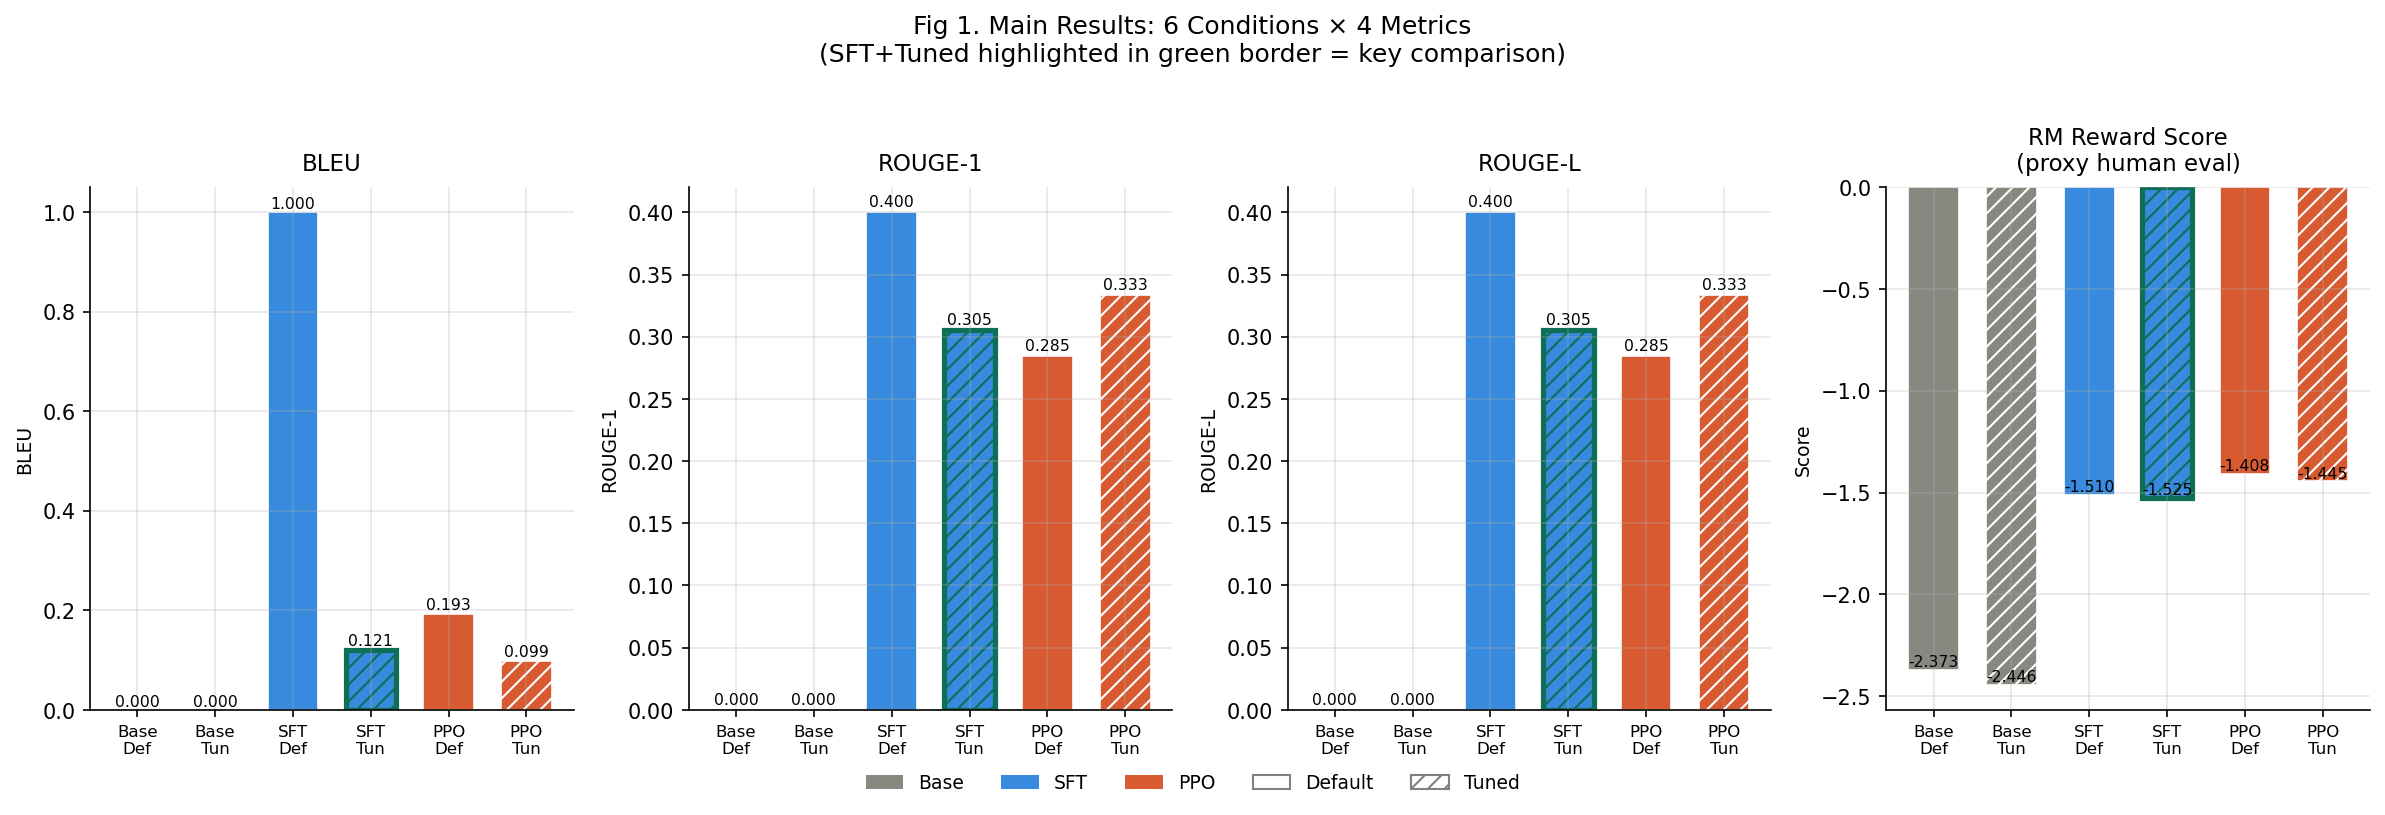

Fig 1 저장 완료


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']
titles  = ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM Reward Score\n(proxy human eval)']

cond_order = ['BASE + Default', 'BASE + Tuned',
              'SFT + Default',  'SFT + Tuned',
              'PPO + Default',  'PPO + Tuned']
x = np.arange(len(cond_order))

for ax, metric, title in zip(axes, metrics, titles):
    vals   = []
    colors = []
    hatches = []
    for cond in cond_order:
        parts = cond.split(' + ')
        m, d = parts[0].strip(), parts[1].strip()
        m_key = m.upper()
        d_key = d.capitalize()
        v = df[(df['model'] == m_key) & (df['decoding'] == d_key)][metric].mean()
        vals.append(v)
        colors.append(COLORS.get(m_key, '#888780'))
        hatches.append(HATCH[d_key])

    bars = ax.bar(x, vals, color=colors, hatch=hatches,
                  edgecolor='white', linewidth=0.8, width=0.65)

    # SFT+Tuned 강조 테두리
    bars[3].set_edgecolor('#0F6E56')
    bars[3].set_linewidth(2.5)

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Base\nDef', 'Base\nTun', 'SFT\nDef', 'SFT\nTun', 'PPO\nDef', 'PPO\nTun'],
        fontsize=8
    )
    ax.set_ylabel(metric if metric != 'RM_Reward' else 'Score', fontsize=9)

    # 수치 레이블
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

# 공통 범례
legend_elements = [
    mpatches.Patch(facecolor=COLORS['Base'],  label='Base'),
    mpatches.Patch(facecolor=COLORS['SFT'],   label='SFT'),
    mpatches.Patch(facecolor=COLORS['PPO'],   label='PPO'),
    mpatches.Patch(facecolor='white', hatch='', edgecolor='gray',  label='Default'),
    mpatches.Patch(facecolor='white', hatch='///', edgecolor='gray', label='Tuned'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Fig 1. Main Results: 6 Conditions × 4 Metrics\n'
             '(SFT+Tuned highlighted in green border = key comparison)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 저장 완료")

### Fig 2. 디코딩 전략의 순수 효과 — Delta 히트맵

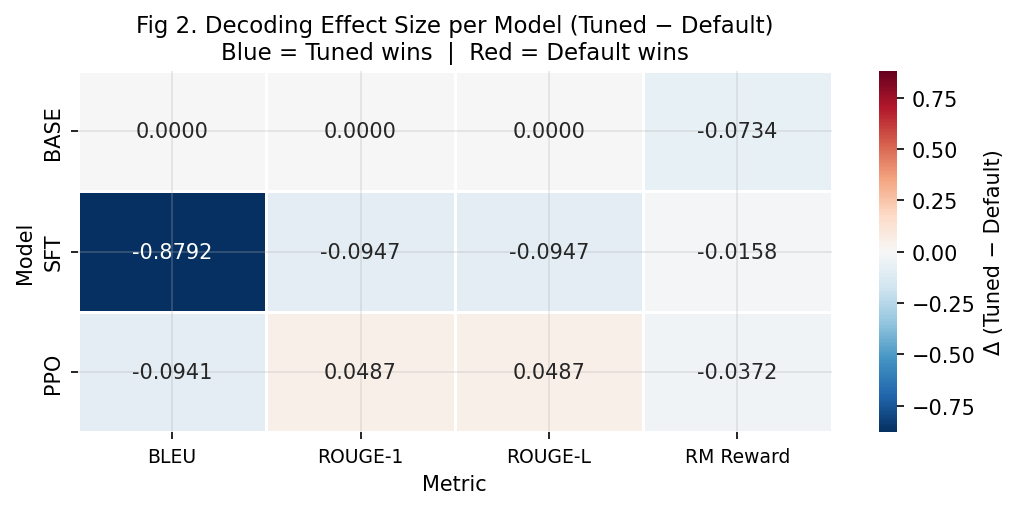

Fig 2 저장 완료


In [26]:
fig, ax = plt.subplots(figsize=(7, 3.5))

pivot = df_delta.pivot(index='model', columns='metric', values='delta')
pivot = pivot.reindex(['BASE', 'SFT', 'PPO'])
pivot = pivot[['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']]

# 발산형 컬러맵: 양수=파랑(Tuned 우세), 음수=빨강(Default 우세)
vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='RdBu_r',
    center=0, vmin=-vmax, vmax=vmax,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Δ (Tuned − Default)'}
)
ax.set_title('Fig 2. Decoding Effect Size per Model (Tuned − Default)\n'
             'Blue = Tuned wins  |  Red = Default wins', fontsize=11)
ax.set_xlabel('Metric', fontsize=10)
ax.set_ylabel('Model', fontsize=10)
ax.set_xticklabels(['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM Reward'], fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_decoding_effect_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 저장 완료")

### Fig 3. 핵심 비교: SFT+Tuned vs PPO+Default (질문별 세부)

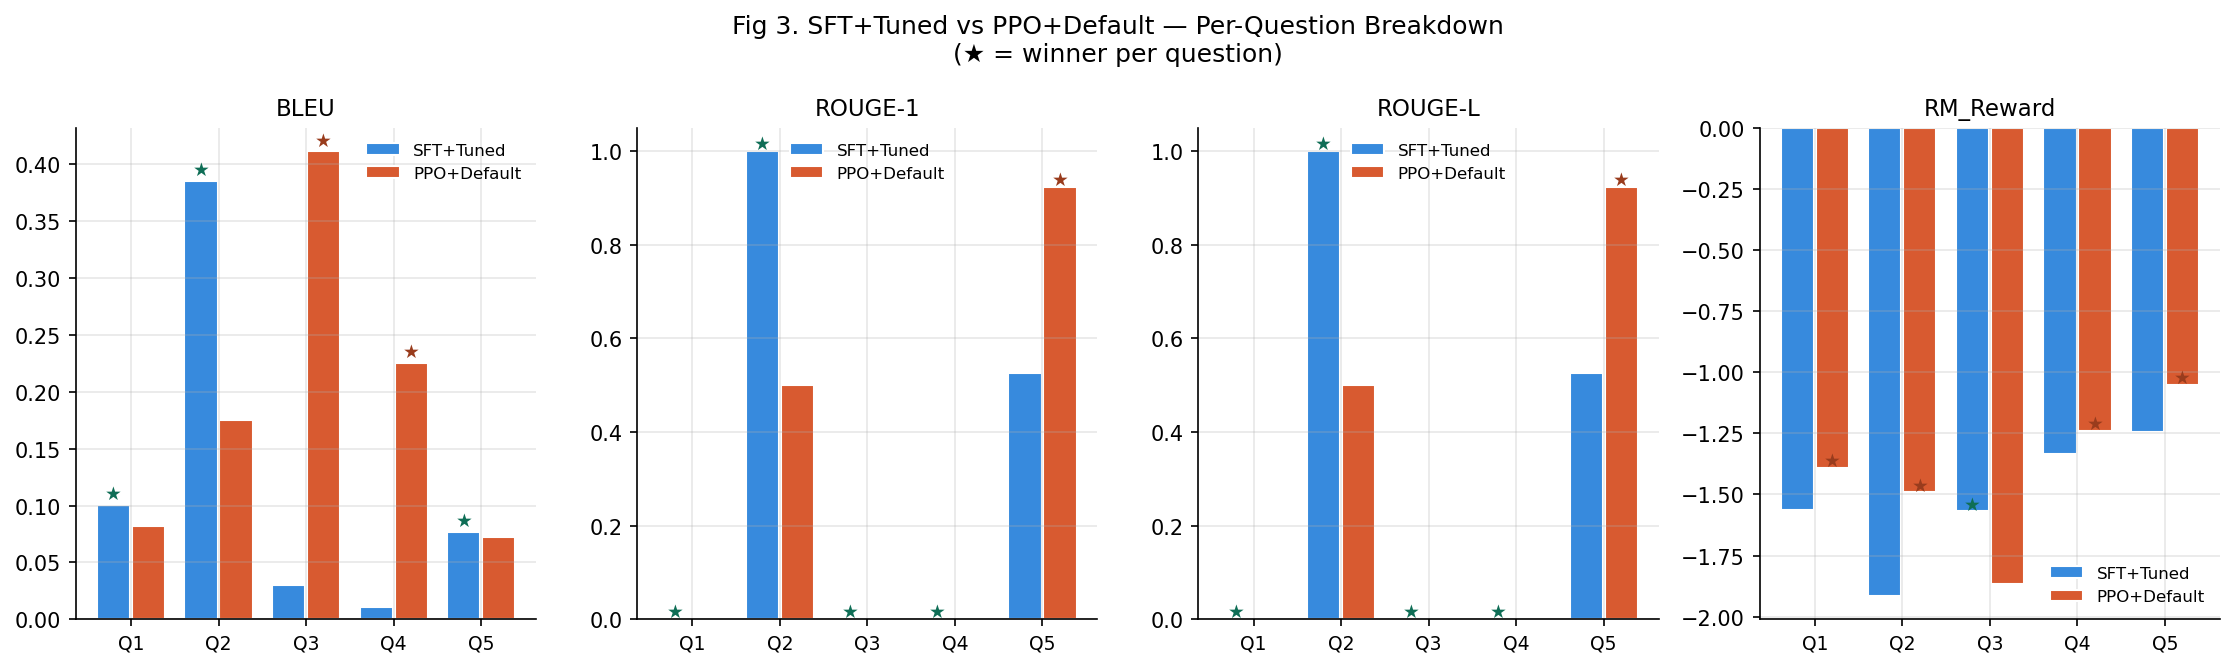

Fig 3 저장 완료


In [27]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

for ax, metric in zip(axes, ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']):
    sft_vals = sft_tuned.sort_values('q_idx')[metric].values
    ppo_vals = ppo_default.sort_values('q_idx')[metric].values
    qs       = [f'Q{i+1}' for i in range(len(EVAL_PROMPTS_RAW))]
    xi       = np.arange(len(qs))

    bars_sft = ax.bar(xi - 0.2, sft_vals, width=0.38,
                      color=COLORS['SFT'], label='SFT+Tuned', edgecolor='white')
    bars_ppo = ax.bar(xi + 0.2, ppo_vals, width=0.38,
                      color=COLORS['PPO'], label='PPO+Default', edgecolor='white')

    ax.set_title(metric, fontsize=11)
    ax.set_xticks(xi)
    ax.set_xticklabels(qs, fontsize=9)
    ax.legend(fontsize=8, frameon=False)

    # 승패 표시
    for i, (sv, pv) in enumerate(zip(sft_vals, ppo_vals)):
        winner_x = xi[i] - 0.2 if sv >= pv else xi[i] + 0.2
        winner_v = max(sv, pv)
        ax.text(winner_x, winner_v + 0.005, '★', ha='center', fontsize=9,
                color='#0F6E56' if sv >= pv else '#993C1D')

fig.suptitle('Fig 3. SFT+Tuned vs PPO+Default — Per-Question Breakdown\n'
             '(★ = winner per question)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig3_sft_tuned_vs_ppo_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 저장 완료")

### Fig 4. RM Reward vs BLEU 산점도 (RM collapse 시각화)

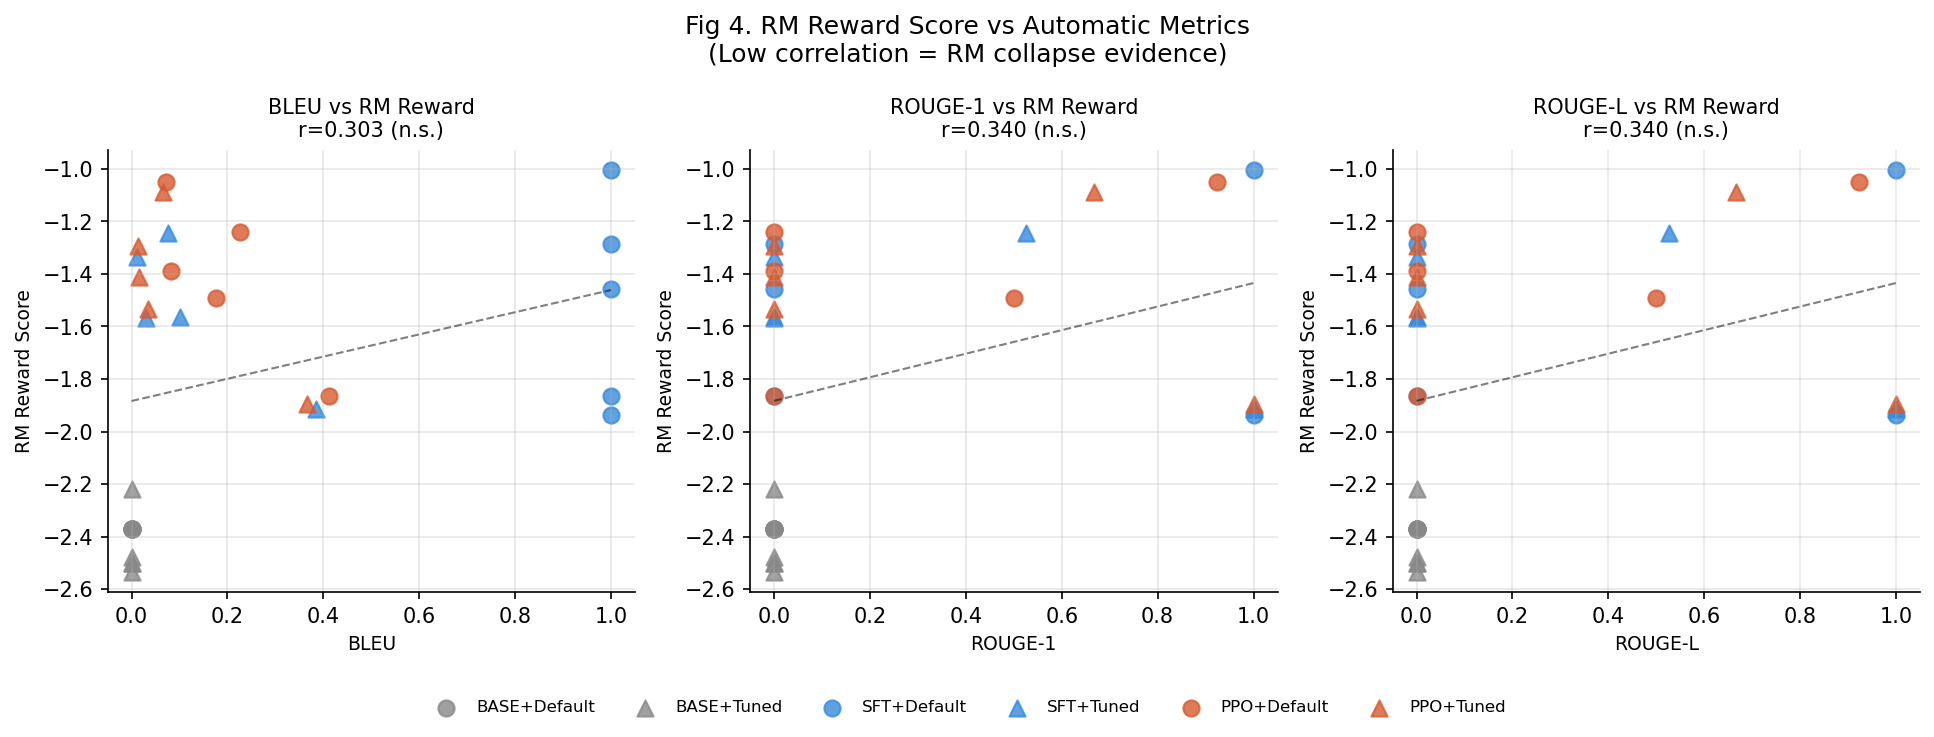

Fig 4 저장 완료


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, metric in zip(axes, ['BLEU', 'ROUGE-1', 'ROUGE-L']):
    for (model_key, dec_key, label) in CONDITIONS:
        subset = df[(df['model'] == model_key.upper()) & (df['decoding'] == dec_key.capitalize())]
        ax.scatter(
            subset[metric], subset['RM_Reward'],
            color=COLORS.get(model_key.upper(), '#888'),
            marker='o' if dec_key == 'default' else '^',
            s=60, alpha=0.8,
            label=f"{model_key.upper()}+{dec_key.capitalize()}"
        )

    # 전체 회귀선
    r, p = stats.pearsonr(df[metric], df['RM_Reward'])
    m_coef, b = np.polyfit(df[metric], df['RM_Reward'], 1)
    x_line = np.linspace(df[metric].min(), df[metric].max(), 50)
    ax.plot(x_line, m_coef * x_line + b, 'k--', alpha=0.5, linewidth=1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.set_title(f'{metric} vs RM Reward\nr={r:.3f} ({sig})', fontsize=10)
    ax.set_xlabel(metric, fontsize=9)
    ax.set_ylabel('RM Reward Score', fontsize=9)

# 공통 범례 (첫 번째 subplot 기준)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Fig 4. RM Reward Score vs Automatic Metrics\n'
             '(Low correlation = RM collapse evidence)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_rm_collapse_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 저장 완료")

### Fig 5. 응답 다양성 비교 — Self-BLEU & Distinct-n

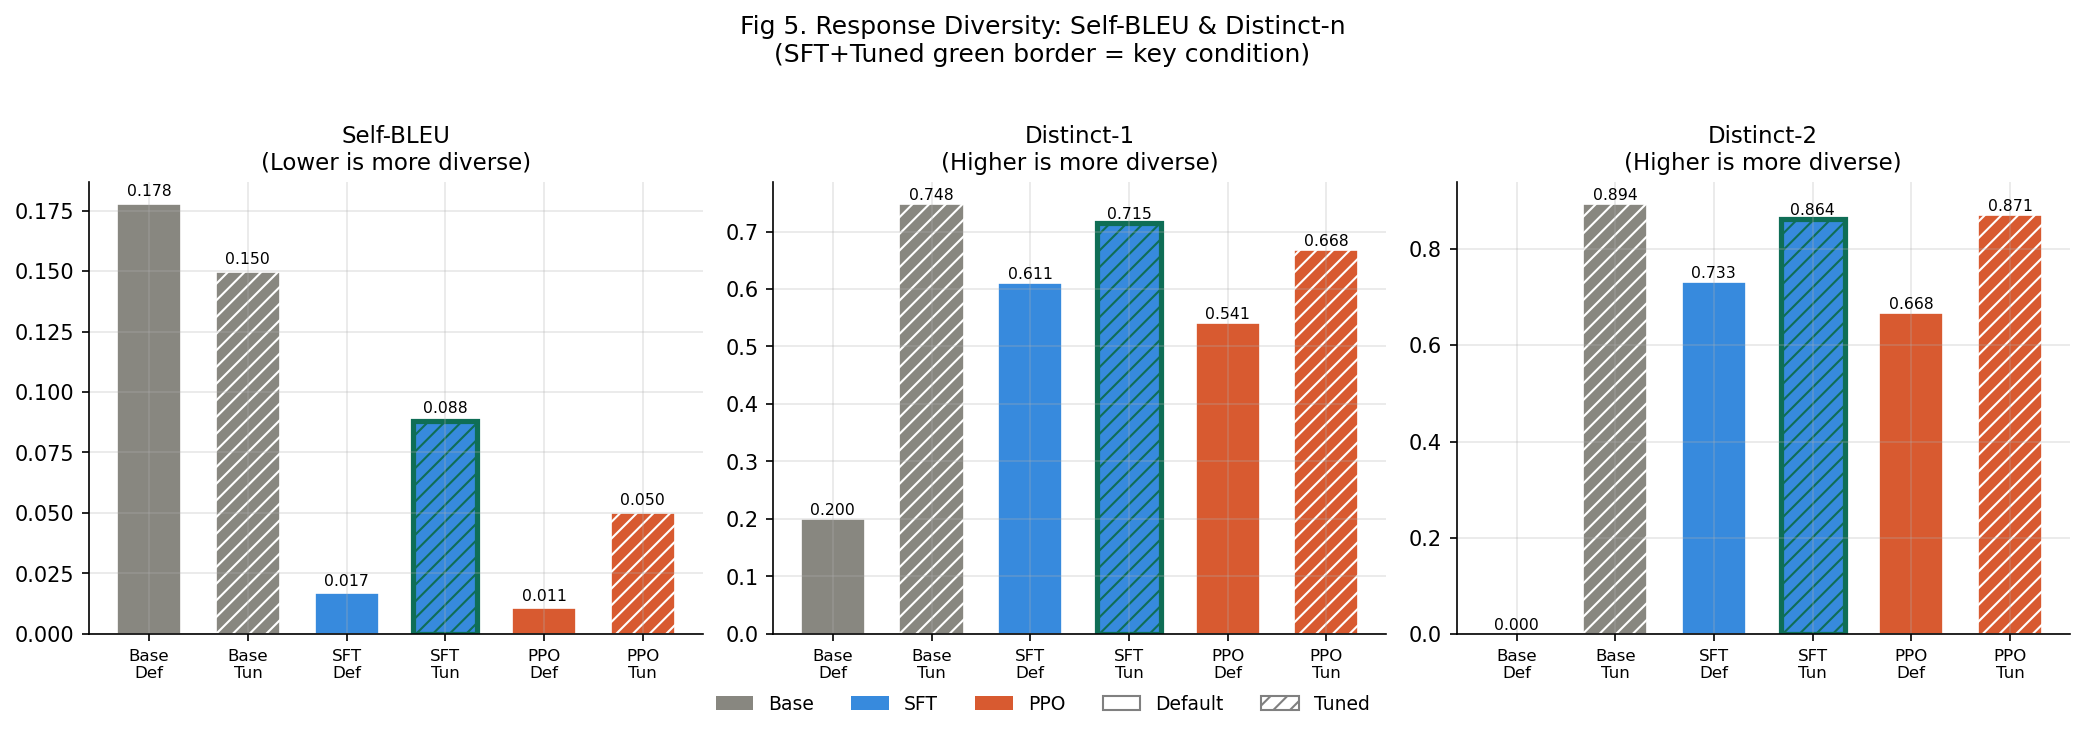

Fig 5 저장 완료


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
div_metrics = [
    ('Self-BLEU',  'Lower is more diverse',  True),   # invert=True: 낮을수록 좋음
    ('Distinct-1', 'Higher is more diverse', False),
    ('Distinct-2', 'Higher is more diverse', False),
]

cond_labels = ['Base\nDef', 'Base\nTun', 'SFT\nDef',
               'SFT\nTun',  'PPO\nDef',  'PPO\nTun']
xi = np.arange(len(CONDITIONS))

for ax, (metric, note, invert) in zip(axes, div_metrics):
    vals    = []
    colors  = []
    hatches = []
    for model_key, dec_key, _ in CONDITIONS:
        row = df_diversity[(df_diversity['model']    == model_key.upper()) &
                           (df_diversity['decoding'] == dec_key.capitalize())]
        vals.append(row[metric].values[0])
        colors.append(COLORS.get(model_key.upper(), '#888780'))
        hatches.append(HATCH[dec_key.capitalize()])

    bars = ax.bar(xi, vals, color=colors, hatch=hatches,
                  edgecolor='white', linewidth=0.8, width=0.65)
    # SFT+Tuned 강조
    bars[3].set_edgecolor('#0F6E56')
    bars[3].set_linewidth(2.5)

    ax.set_title(f'{metric}\n({note})', fontsize=11)
    ax.set_xticks(xi)
    ax.set_xticklabels(cond_labels, fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

legend_elements = [
    mpatches.Patch(facecolor=COLORS['Base'], label='Base'),
    mpatches.Patch(facecolor=COLORS['SFT'],  label='SFT'),
    mpatches.Patch(facecolor=COLORS['PPO'],  label='PPO'),
    mpatches.Patch(facecolor='white', hatch='',    edgecolor='gray', label='Default'),
    mpatches.Patch(facecolor='white', hatch='///', edgecolor='gray', label='Tuned'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Fig 5. Response Diversity: Self-BLEU & Distinct-n\n'
             '(SFT+Tuned green border = key condition)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig5_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 저장 완료")

### Fig 6. 효율성 비교 — 추론 시간 & VRAM (성능 대비 비용)

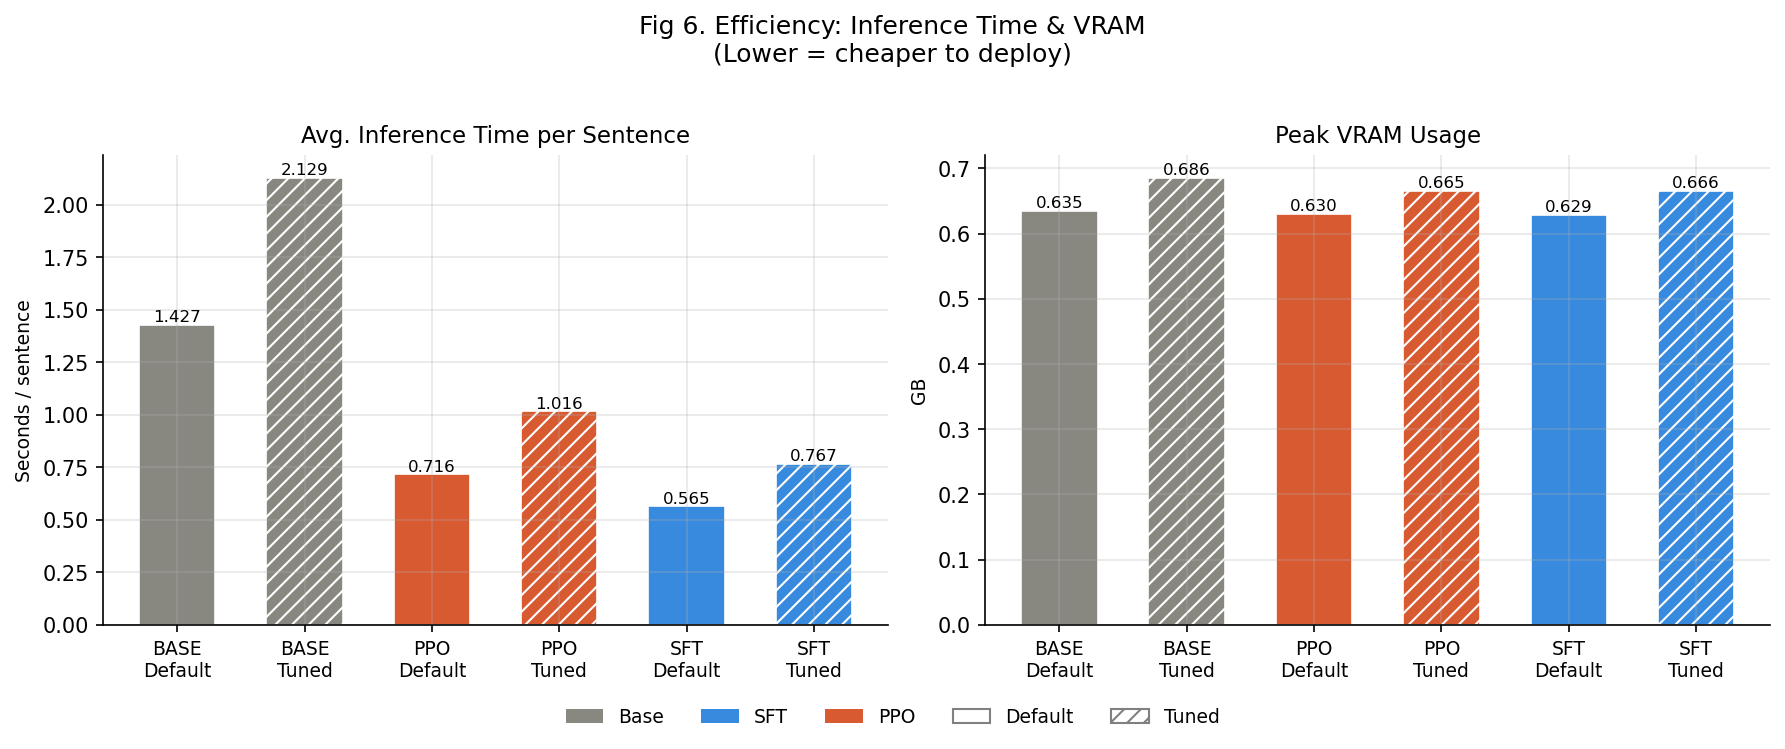

Fig 6 저장 완료


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

eff_cond  = eff_summary.reset_index()
eff_cond['label'] = eff_cond['model'] + '\n' + eff_cond['decoding']
x_eff     = np.arange(len(eff_cond))
eff_colors = [COLORS.get(r['model'], '#888780') for _, r in eff_cond.iterrows()]
eff_hatch  = [HATCH.get(r['decoding'], '') for _, r in eff_cond.iterrows()]

for ax, metric, ylabel, title in [
    (axes[0], 'time_sec',     'Seconds / sentence', 'Avg. Inference Time per Sentence'),
    (axes[1], 'vram_peak_gb', 'GB',                 'Peak VRAM Usage'),
]:
    bars = ax.bar(x_eff, eff_cond[metric], color=eff_colors,
                  hatch=eff_hatch, edgecolor='white', linewidth=0.8, width=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x_eff)
    ax.set_xticklabels(eff_cond['label'], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    for bar, v in zip(bars, eff_cond[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Fig 6. Efficiency: Inference Time & VRAM\n'
             '(Lower = cheaper to deploy)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig6_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 6 저장 완료")

### Fig 7. 텍스트 길이 vs RM Reward (Length Bias 시각화)

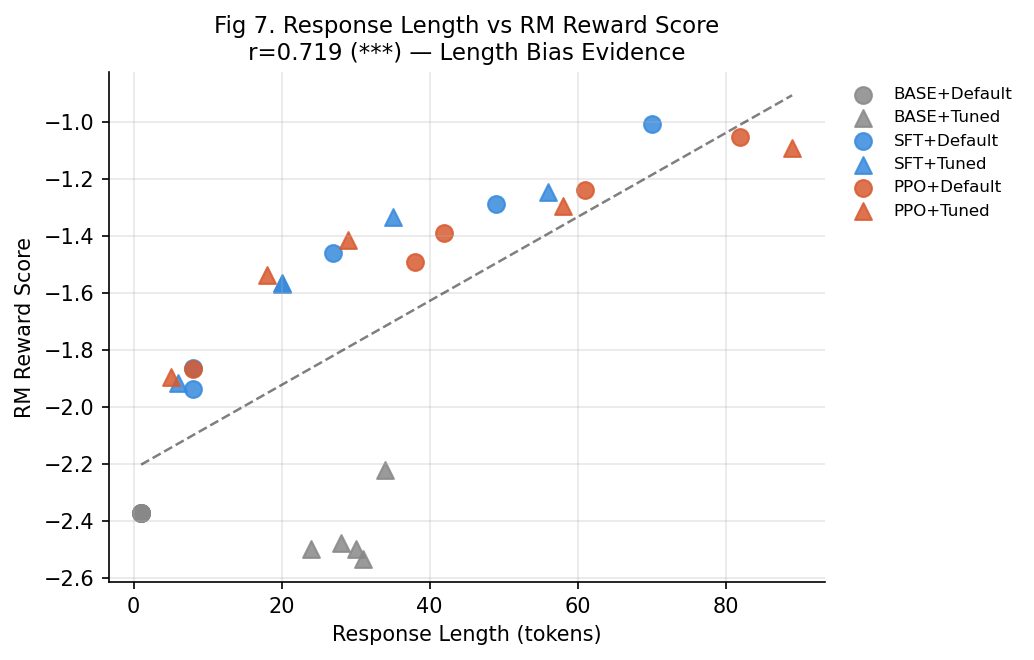

Fig 7 저장 완료


In [31]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for model_key, dec_key, label in CONDITIONS:
    subset = df[(df['model'] == model_key.upper()) & (df['decoding'] == dec_key.capitalize())]
    ax.scatter(
        subset['resp_len'], subset['RM_Reward'],
        color=COLORS.get(model_key.upper(), '#888'),
        marker='o' if dec_key == 'default' else '^',
        s=65, alpha=0.85, label=f"{model_key.upper()}+{dec_key.capitalize()}"
    )

# 회귀선
m_len, b_len = np.polyfit(df['resp_len'], df['RM_Reward'], 1)
x_line = np.linspace(df['resp_len'].min(), df['resp_len'].max(), 50)
ax.plot(x_line, m_len * x_line + b_len, 'k--', alpha=0.5, linewidth=1.2)

sig_label = "***" if p_len < 0.001 else ("**" if p_len < 0.01 else ("*" if p_len < 0.05 else "n.s."))
ax.set_title(f'Fig 7. Response Length vs RM Reward Score\n'
             f'r={r_len:.3f} ({sig_label}) — Length Bias Evidence',
             fontsize=11)
ax.set_xlabel('Response Length (tokens)', fontsize=10)
ax.set_ylabel('RM Reward Score', fontsize=10)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig7_length_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 저장 완료")

## 8. 최종 요약 출력

In [32]:
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

summary_mean = df.groupby('condition')[['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']].mean().round(4)
print("\n[전체 조건 평균 지표]")
print(summary_mean.to_string())

print("\n[다양성 지표]")
print(df_diversity[['condition', 'Self-BLEU', 'Distinct-1', 'Distinct-2']].to_string(index=False))

print("\n[효율성 지표]")
print(eff_summary.to_string())

sft_t = df[df['condition'] == 'SFT + Tuned'][['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']].mean()
ppo_d = df[df['condition'] == 'PPO + Default'][['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']].mean()

print("\n[핵심 비교: SFT+Tuned vs PPO+Default]")
for metric in ['BLEU', 'ROUGE-1', 'ROUGE-L', 'RM_Reward']:
    diff   = sft_t[metric] - ppo_d[metric]
    winner = "SFT+Tuned ✓" if diff >= 0 else "PPO+Default ✓"
    print(f"  {metric:<12}: SFT+Tuned={sft_t[metric]:.4f}  PPO+Default={ppo_d[metric]:.4f}"
          f"  Δ={diff:+.4f}  → {winner}")

print(f"\n[Length Bias 검증]  r(resp_len, RM_Reward)={r_len:.3f}  p={p_len:.4f}  {sig_label}")
if abs(r_len) > 0.3:
    print("  → RM이 응답 길이에 편향되어 있을 가능성 있음 (Discussion에 명시 권장)")
else:
    print("  → 길이 편향 약함, RM collapse의 원인을 다른 곳에서 탐색 필요")

print(f"\n저장된 파일:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {SAVE_DIR}/{f}")
print("\n실험 완료!")



FINAL SUMMARY

[전체 조건 평균 지표]
                    BLEU  ROUGE-1  ROUGE-L  RM_Reward
condition                                            
Base   + Default  0.0000   0.0000   0.0000    -2.3725
Base   + Tuned    0.0000   0.0000   0.0000    -2.4459
PPO    + Default  0.1932   0.2846   0.2846    -1.4075
PPO    + Tuned    0.0991   0.3333   0.3333    -1.4447
SFT    + Default  1.0000   0.4000   0.4000    -1.5096
SFT    + Tuned    0.1208   0.3053   0.3053    -1.5253

[다양성 지표]
       condition  Self-BLEU  Distinct-1  Distinct-2
Base   + Default     0.1778      0.2000      0.0000
  Base   + Tuned     0.1496      0.7483      0.8944
SFT    + Default     0.0168      0.6111      0.7325
  SFT    + Tuned     0.0880      0.7153      0.8636
PPO    + Default     0.0105      0.5411      0.6681
  PPO    + Tuned     0.0500      0.6683      0.8711

[효율성 지표]
                time_sec  vram_peak_gb
model decoding                        
BASE  Default      1.427         0.635
      Tuned        2.129         0.68